# Main figure 3: amplitude robustness

This notebook extracts a signed-Gaussian center, FWHM, contrast, and covariance-based center precision from every fixed-amplitude slice of the measured echo-root-Lorentzian sweep. Failed quality gates remain missing values; they are never converted into zero-width results. The Gaussian is an operational estimator, not a claim about the exact physical line shape.

In [1]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'echospec').is_dir())
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.codex_tmp' / 'mpl'))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

from echospec.figures import FigureVariant, apply_figure_style, save_figure

VARIANT = FigureVariant.PAPER
apply_figure_style(VARIANT)

DATA_PATH = PROJECT_ROOT / 'ips_plots/data/lorentzian_echo/echo_lorentzian_12-33-44-667799_data_bundle.npz'
EDGE_POINTS = 40
SMOOTH_SIGMA_POINTS = 1.0
INITIAL_SIGMA_MHZ = 0.040
MIN_CONTRAST = 0.02
MAX_FWHM_MHZ = 0.12
MAX_ABS_CENTER_MHZ = 0.050
REFERENCE_OFFSET_MHZ = 0.0

In [2]:
def load_amplitude_sweep(path):
    with np.load(path, allow_pickle=True) as bundle:
        qubits = json.loads(bundle['profile__qubits.json'].item())['qubits']
        pulses = json.loads(bundle['profile__pulses.json'].item())['pulses']
        qubit = str(bundle['data__qubit'][0])
        x180_name = qubits[qubit]['operations']['x180']
        pi_pulse = pulses[qubit][x180_name]
        amp_prefactor = np.asarray(bundle['data__amp_prefactor'], dtype=float)
        pi_rabi_mhz = 1000 / (2 * pi_pulse['length_ns'])
        rabi_mhz = amp_prefactor / pi_pulse['amplitude'] * pi_rabi_mhz
        return (
            np.asarray(bundle['data__detuning'], dtype=float) / 1e6,
            rabi_mhz,
            np.asarray(bundle['data__state'][0], dtype=float),
            qubit,
        )

def dip_gaussian(detuning_mhz, offset, depth, center_mhz, sigma_mhz):
    return offset - depth * np.exp(-0.5 * ((detuning_mhz - center_mhz) / sigma_mhz) ** 2)

detuning_mhz, rabi_mhz, state, qubit = load_amplitude_sweep(DATA_PATH)
print(f'Loaded {state.shape[1]} amplitude slices for {qubit}.')

Loaded 100 amplitude slices for q1.


In [3]:
def fit_slice(detuning_mhz, trace):
    x = np.asarray(detuning_mhz[EDGE_POINTS:-EDGE_POINTS], dtype=float)
    y = gaussian_filter1d(np.asarray(trace[EDGE_POINTS:-EDGE_POINTS], dtype=float), SMOOTH_SIGMA_POINTS)
    step = float(np.median(np.diff(x)))
    span = float(x.max() - x.min())
    edge_count = max(5, x.size // 10)
    offset0 = float(np.median(np.r_[y[:edge_count], y[-edge_count:]]))
    minimum_index = int(np.argmin(y))
    depth0 = max(offset0 - float(y[minimum_index]), 1e-3)
    center0 = float(x[minimum_index])

    try:
        values, covariance = curve_fit(
            dip_gaussian,
            x,
            y,
            p0=[offset0, depth0, center0, INITIAL_SIGMA_MHZ],
            bounds=(
                [-0.2, 0.0, x.min(), abs(step) / 2],
                [1.2, 1.2, x.max(), span],
            ),
            maxfev=20_000,
        )
        errors = np.sqrt(np.diag(covariance))
    except Exception as exc:
        return {'valid': False, 'reason': type(exc).__name__}

    offset, depth, center, sigma = values
    offset_error, depth_error, center_error, sigma_error = errors
    factor = 2 * np.sqrt(2 * np.log(2))
    fwhm = factor * abs(sigma)
    fwhm_error = factor * sigma_error

    reasons = []
    if not np.all(np.isfinite(np.r_[values, errors])):
        reasons.append('nonfinite')
    if depth < MIN_CONTRAST:
        reasons.append('low contrast')
    if fwhm > MAX_FWHM_MHZ:
        reasons.append('too broad')
    if abs(center) > MAX_ABS_CENTER_MHZ:
        reasons.append('center outside gate')

    return {
        'valid': not reasons,
        'reason': ', '.join(reasons) if reasons else 'accepted',
        'offset': offset,
        'offset_error': offset_error,
        'contrast': depth,
        'contrast_error': depth_error,
        'center_mhz': center,
        'center_error_mhz': center_error,
        'fwhm_mhz': fwhm,
        'fwhm_error_mhz': fwhm_error,
    }

rows = []
for index, amplitude in enumerate(rabi_mhz):
    row = {'rabi_mhz': float(amplitude)}
    row.update(fit_slice(detuning_mhz, state[:, index]))
    rows.append(row)
def fit_column(name, default=np.nan, dtype=float):
    return np.asarray([row.get(name, default) for row in rows], dtype=dtype)

fits = {
    'rabi_mhz': fit_column('rabi_mhz'),
    'valid': fit_column('valid', False, bool),
    'reason': fit_column('reason', 'unknown', str),
}
for name in ['contrast', 'contrast_error', 'center_mhz', 'center_error_mhz', 'fwhm_mhz', 'fwhm_error_mhz']:
    fits[name] = fit_column(name)
fits['frequency_error_mhz'] = fits['center_mhz'] - REFERENCE_OFFSET_MHZ

print(f"Accepted {fits['valid'].sum()} of {len(rows)} amplitude slices.")
print(Counter(fits['reason'][~fits['valid']]))
{name: values[:5] for name, values in fits.items()}

Accepted 62 of 100 amplitude slices.
Counter({np.str_('too broad'): 30, np.str_('center outside gate'): 7, np.str_('low contrast, center outside gate'): 1})


{'rabi_mhz': array([0.        , 0.77354175, 1.5470835 , 2.32062525, 3.094167  ]),
 'valid': array([False, False, False, False, False]),
 'reason': array(['center outside gate', 'low contrast, center outside gate',
        'center outside gate', 'center outside gate',
        'center outside gate'], dtype='<U33'),
 'contrast': array([0.07161874, 0.01600337, 0.05339073, 0.05252069, 0.04601008]),
 'contrast_error': array([0.54341873, 0.00407616, 0.01411516, 0.01069106, 0.01112822]),
 'center_mhz': array([ 0.4596451 ,  0.10418842,  0.22542615, -0.16951726,  0.10677734]),
 'center_error_mhz': array([0.00241275, 0.0047627 , 0.0004839 , 0.00066375, 0.00078088]),
 'fwhm_mhz': array([0.00117741, 0.03835237, 0.00373459, 0.00665586, 0.00659017]),
 'fwhm_error_mhz': array([0.00974168, 0.01140766, 0.00114124, 0.00156734, 0.00184387]),
 'frequency_error_mhz': array([ 0.4596451 ,  0.10418842,  0.22542615, -0.16951726,  0.10677734])}

[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness.svg')]

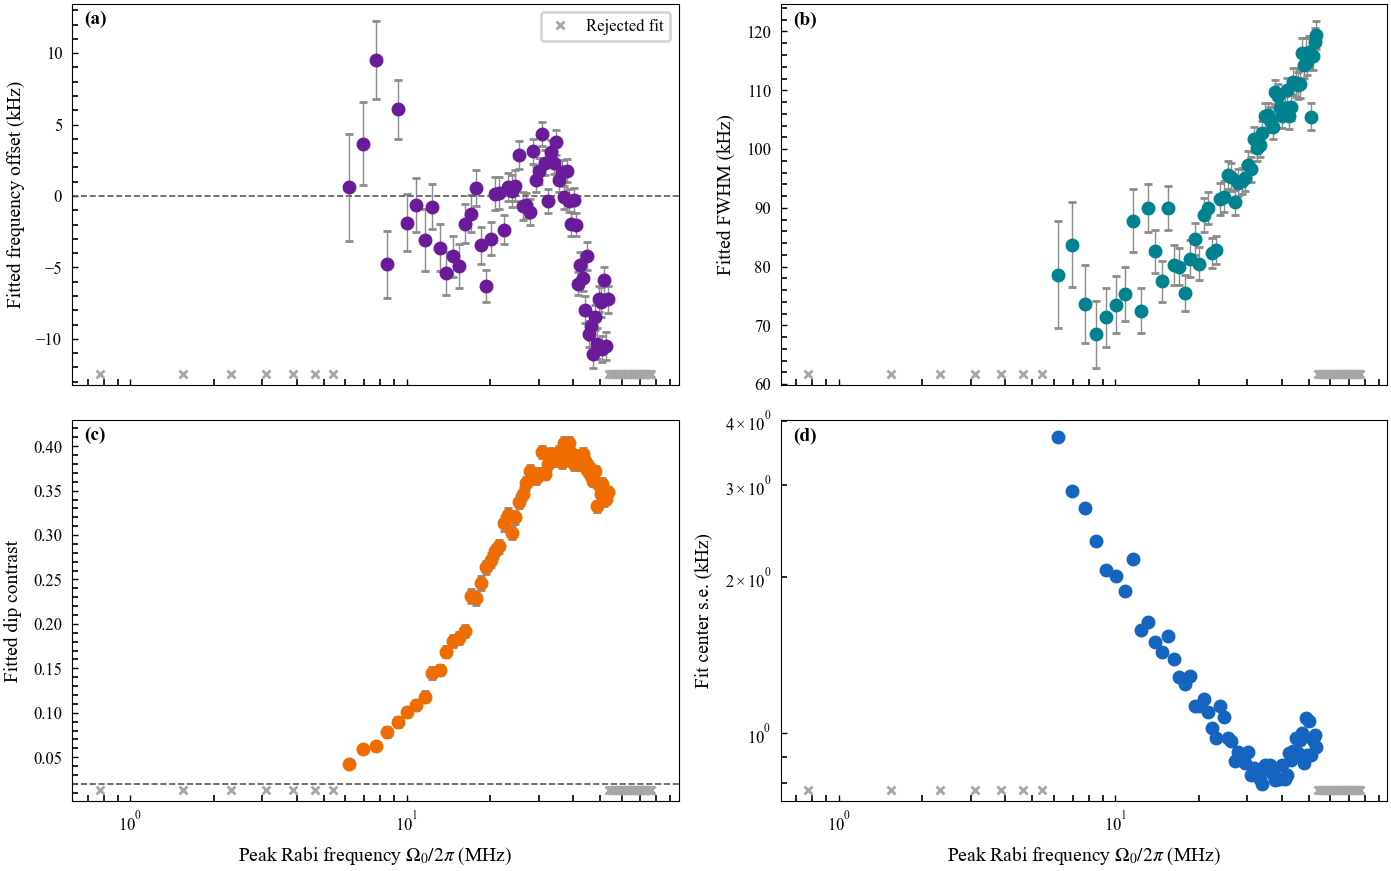

In [4]:
accepted = fits['valid'] & (fits['rabi_mhz'] > 0)
rejected = (~fits['valid']) & (fits['rabi_mhz'] > 0)
x = fits['rabi_mhz'][accepted]

fig, axes = plt.subplots(2, 2, figsize=(7.0, 4.4), sharex=True, constrained_layout=True)

axes[0, 0].errorbar(x, fits['frequency_error_mhz'][accepted] * 1e3, yerr=fits['center_error_mhz'][accepted] * 1e3, fmt='o', color='#6a1b9a', ecolor='0.55', capsize=1.5)
axes[0, 0].axhline(0, color='0.35', ls='--', lw=0.6)
axes[0, 0].set_ylabel('Fitted frequency offset (kHz)')

axes[0, 1].errorbar(x, fits['fwhm_mhz'][accepted] * 1e3, yerr=fits['fwhm_error_mhz'][accepted] * 1e3, fmt='o', color='#00838f', ecolor='0.55', capsize=1.5)
axes[0, 1].set_ylabel('Fitted FWHM (kHz)')

axes[1, 0].errorbar(x, fits['contrast'][accepted], yerr=fits['contrast_error'][accepted], fmt='o', color='#ef6c00', ecolor='0.55', capsize=1.5)
axes[1, 0].axhline(MIN_CONTRAST, color='0.35', ls='--', lw=0.6)
axes[1, 0].set_ylabel('Fitted dip contrast')

axes[1, 1].plot(x, fits['center_error_mhz'][accepted] * 1e3, 'o', color='#1565c0')
axes[1, 1].set_yscale('log')
axes[1, 1].set_ylabel('Fit center s.e. (kHz)')

for label, ax in zip(['(a)', '(b)', '(c)', '(d)'], axes.flat):
    ax.set_xscale('log')
    ax.plot(fits['rabi_mhz'][rejected], np.full(rejected.sum(), 0.03), 'x', color='0.65', ms=3, transform=ax.get_xaxis_transform(), label='Rejected fit' if label == '(a)' else None)
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha='left', va='top', fontweight='bold')

axes[1, 0].set_xlabel(r'Peak Rabi frequency $\Omega_0/2\pi$ (MHz)')
axes[1, 1].set_xlabel(r'Peak Rabi frequency $\Omega_0/2\pi$ (MHz)')
axes[0, 0].legend(loc='best')

saved = save_figure(fig, '03_amplitude_robustness', variant=VARIANT)
saved

### Statistical caveat

The center precision in panel (d) is the standard error obtained from the local least-squares covariance matrix after smoothing. It is a fit diagnostic, not yet a repeated-experiment frequency RMSE or a per-shot Cramér–Rao bound. A submission-quality uncertainty should be checked with shot-level bootstrap resampling or repeated sweeps.